# Ridge Regression — Expanded Features

Extends the baseline ridge model (`02_ridge_model`) with non-linear transformations and interaction terms to capture non-linear structure–MP relationships. All features are derived from the same structural descriptors; no experimental measurements are added.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [2]:
df = pl.read_parquet("../data/processed/baseline_model_features.parquet")
print(df.shape)
df.head()

(3024, 38)


key,name,smiles,mpC,formula,C_count,H_count,O_count,N_count,S_count,F_count,Cl_count,Br_count,I_count,molecular_weight,branch_count,cycle_count,aromatic_ring_count,double_bond_count,triple_bond_count,carboxylic_acid_count,alcohol_count,carbonyl_count,prim_sec_amine_count,amide_count,hbd_count,hba_count,logp,tpsa,rotatable_bond_count,frac_csp3,stereocenters,bertz_ct,bridgehead_atoms,spiro_atoms,heterocycle_count,ring_atom_ratio,split
i64,str,str,f64,str,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,i32,f64,i32,f64,i32,i32,i32,f64,str
27956,"""cyclobutylmethane""","""C1(CCC1)C""",-161.51,"""C5H10""",5,10,0,0,0,0,0,0,0,70.135,0,1,0,0,0,0,0,0,0,0,0,0,1.8064,0.0,0,1.0,0,27.01955,0,0,0,0.8,"""train"""
16005,"""Nitrogen oxide""","""[O-][N+]#N""",-90.8,"""N2O""",0,0,1,2,0,0,0,0,0,44.013,0,0,0,0,1,0,0,0,0,0,0,2,0.33728,51.21,0,0.0,0,24.264663,0,0,0,0.0,"""train"""
16127,"""Sulfuryl difluoride""","""FS(F)(=O)=O""",-135.8,"""F2O2S""",0,0,2,0,1,2,0,0,0,102.061,1,0,0,2,0,0,0,0,0,0,0,2,0.1702,34.14,0,0.0,0,90.816358,0,0,0,0.0,"""train"""
17138,"""disopyramide""","""CC(C)N(CCC(c1ccccn1)(c2ccccc2)…",94.8,"""C21H29N3O""",21,29,1,3,0,0,0,0,0,339.483,5,2,2,1,0,0,0,1,0,1,1,3,3.3619,59.22,8,0.428571,1,620.555222,0,0,1,0.48,"""train"""
15628,"""Bromine""","""BrBr""",-7.2,"""Br2""",0,0,0,0,0,0,0,2,0,159.808,0,0,0,0,0,0,0,0,0,0,0,0,1.6912,0.0,0,0.0,0,0.0,0,0,0,0.0,"""test"""


## Train / Tune / Test Split

Split assignments are loaded from `baseline_model_features.parquet` (assigned in `01_feature_engineering`).

In [3]:
BASE_FEATURE_COLS = [c for c in df.columns if c not in ("key", "name", "smiles", "mpC", "formula", "split")]

train_df = df.filter(pl.col("split") == "train")
tune_df  = df.filter(pl.col("split") == "tune")
test_df  = df.filter(pl.col("split") == "test")

y_train   = train_df["mpC"].to_numpy()
y_tune    = tune_df["mpC"].to_numpy()
y_test    = test_df["mpC"].to_numpy()
keys_test = test_df["key"].to_numpy()

print(f"Train: {len(y_train)}  Tune: {len(y_tune)}  Test: {len(y_test)}")

Train: 2116  Tune: 299  Test: 609


## Feature Expansion

Four categories of new features are added on top of the baseline descriptors.

**Non-linear transforms** on continuous descriptors whose relationship with MP is unlikely to be linear:
- `log1p(molecular_weight)` — MP scales sub-linearly with mass
- `sqrt(molecular_weight)`
- `log1p(bertz_ct)` — complexity spans many orders of magnitude; log compresses the range
- `log1p(tpsa)` — polar surface area effect diminishes at high values
- `logp²` — LogP can be negative; squaring captures symmetric non-linearity around zero
- `log1p(rotatable_bond_count)` — entropic penalty for flexibility grows sub-linearly
- `log1p(hba_count)`, `log1p(hbd_count)`

**Interaction terms** between descriptors that jointly determine crystal-packing stability:
- `mw × logp` — large hydrophobic molecules pack differently from small ones
- `hbd × hba` — potential for a strong H-bond network (both donor and acceptor needed)
- `logp × tpsa` — complementary polarity descriptors; their product distinguishes amphiphiles
- `aromatic_rings × ring_atom_ratio` — degree of aromatic character drives π–π stacking
- `cycle_count × aromatic_ring_count` — planarity / ring fusion effect
- `heavy_halogen_count × molecular_weight` — heavier halogens contribute disproportionately to mass and London dispersion
- `tpsa × hbd_count` — high TPSA with many H-bond donors is qualitatively distinct from high TPSA without donors
- `frac_csp3 × logp` — distinguishes aliphatic vs. aromatic sources of hydrophobicity
- `frac_csp3 × rotatable_bond_count` — flexible aliphatic chains are a primary driver of low MPs

**Density features** (property ÷ molecular size) — a linear model cannot represent `A / B` from `A` and `B` alone, so ratios are genuinely new information:
- `tpsa / molecular_weight` — polarity per unit mass; isolates intrinsic polarity from size
- `logp / sqrt_mw` — hydrophobicity density
- `hbd_count / molecular_weight`, `hba_count / molecular_weight` — H-bond donor/acceptor density
- `rotatable_bond_count / molecular_weight` — flexibility density; separates chain flexibility from chain length
- `aromatic_ring_count / (cycle_count + 1)` — fraction of rings that are aromatic

**Aggregate features** that capture chemically meaningful totals:
- `total_halogen_count` — any halogenation raises MP via increased polarizability
- `heavy_halogen_count` (Cl + Br + I only)

In [4]:
def add_expanded_features(frame: pl.DataFrame) -> pl.DataFrame:
    return frame.with_columns([
        # Non-linear transforms
        pl.col("molecular_weight").log1p().alias("log_mw"),
        pl.col("molecular_weight").sqrt().alias("sqrt_mw"),
        pl.col("bertz_ct").log1p().alias("log_bertz_ct"),
        pl.col("tpsa").log1p().alias("log_tpsa"),
        (pl.col("logp") ** 2).alias("logp_sq"),
        pl.col("rotatable_bond_count").cast(pl.Float64).log1p().alias("log_rotatable"),
        pl.col("hba_count").cast(pl.Float64).log1p().alias("log_hba"),
        pl.col("hbd_count").cast(pl.Float64).log1p().alias("log_hbd"),

        # Interaction terms
        (pl.col("molecular_weight") * pl.col("logp")).alias("mw_x_logp"),
        (pl.col("hbd_count") * pl.col("hba_count")).cast(pl.Float64).alias("hbd_x_hba"),
        (pl.col("logp") * pl.col("tpsa")).alias("logp_x_tpsa"),
        (pl.col("aromatic_ring_count") * pl.col("ring_atom_ratio")).alias("arom_x_ring_ratio"),
        (pl.col("cycle_count") * pl.col("aromatic_ring_count")).cast(pl.Float64).alias("cycle_x_arom"),
        (
            (pl.col("Cl_count") + pl.col("Br_count") + pl.col("I_count")).cast(pl.Float64)
            * pl.col("molecular_weight")
        ).alias("heavy_halogen_x_mw"),
        (pl.col("tpsa") * pl.col("hbd_count").cast(pl.Float64)).alias("tpsa_x_hbd"),
        (pl.col("frac_csp3") * pl.col("logp")).alias("frac_csp3_x_logp"),
        (pl.col("frac_csp3") * pl.col("rotatable_bond_count").cast(pl.Float64)).alias("frac_csp3_x_rotatable"),

        # Density features (property per unit mass / size)
        (pl.col("tpsa") / pl.col("molecular_weight")).alias("tpsa_per_mw"),
        (pl.col("logp") / pl.col("molecular_weight").sqrt()).alias("logp_per_sqrt_mw"),
        (pl.col("hbd_count").cast(pl.Float64) / pl.col("molecular_weight")).alias("hbd_per_mw"),
        (pl.col("hba_count").cast(pl.Float64) / pl.col("molecular_weight")).alias("hba_per_mw"),
        (pl.col("rotatable_bond_count").cast(pl.Float64) / pl.col("molecular_weight")).alias("rotatable_per_mw"),
        (
            pl.col("aromatic_ring_count").cast(pl.Float64)
            / (pl.col("cycle_count").cast(pl.Float64) + 1)
        ).alias("arom_ring_fraction"),

        # Aggregate counts
        (pl.col("F_count") + pl.col("Cl_count") + pl.col("Br_count") + pl.col("I_count"))
            .alias("total_halogen_count"),
        (pl.col("Cl_count") + pl.col("Br_count") + pl.col("I_count"))
            .alias("heavy_halogen_count"),
    ])


train_exp = add_expanded_features(train_df)
tune_exp  = add_expanded_features(tune_df)
test_exp  = add_expanded_features(test_df)

EXPANDED_COLS = [c for c in train_exp.columns if c not in ("key", "name", "smiles", "mpC", "formula", "split")]
print(f"Baseline features: {len(BASE_FEATURE_COLS)}")
print(f"Expanded features: {len(EXPANDED_COLS)}")
print(f"New features added: {set(EXPANDED_COLS) - set(BASE_FEATURE_COLS)}")

Baseline features: 32
Expanded features: 57
New features added: {'mw_x_logp', 'sqrt_mw', 'arom_ring_fraction', 'log_hbd', 'log_rotatable', 'rotatable_per_mw', 'heavy_halogen_count', 'tpsa_per_mw', 'hbd_x_hba', 'heavy_halogen_x_mw', 'frac_csp3_x_rotatable', 'total_halogen_count', 'log_hba', 'hbd_per_mw', 'logp_sq', 'log_tpsa', 'cycle_x_arom', 'arom_x_ring_ratio', 'log_mw', 'hba_per_mw', 'logp_x_tpsa', 'logp_per_sqrt_mw', 'log_bertz_ct', 'tpsa_x_hbd', 'frac_csp3_x_logp'}


## Feature Scaling

Fit `StandardScaler` on the training set only and apply to tune and test.

In [5]:
X_train = train_exp.select(EXPANDED_COLS).to_numpy()
X_tune  = tune_exp.select(EXPANDED_COLS).to_numpy()
X_test  = test_exp.select(EXPANDED_COLS).to_numpy()

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_tune_s  = scaler.transform(X_tune)
X_test_s  = scaler.transform(X_test)

## Tune α

Search 100 values of α on a log scale from 10⁻² to 10⁵. Pick the value with the lowest MAE on the tuning set.

In [6]:
alphas = np.logspace(-5, 5, 100)
tune_maes = []

for alpha in alphas:
    preds = Ridge(alpha=alpha).fit(X_train_s, y_train).predict(X_tune_s)
    tune_maes.append(mean_absolute_error(y_tune, preds))

best_alpha = alphas[np.argmin(tune_maes)]
print(f"Best α: {best_alpha:.4f}  (tune MAE: {min(tune_maes):.2f} °C)")

Best α: 0.0000  (tune MAE: 34.52 °C)


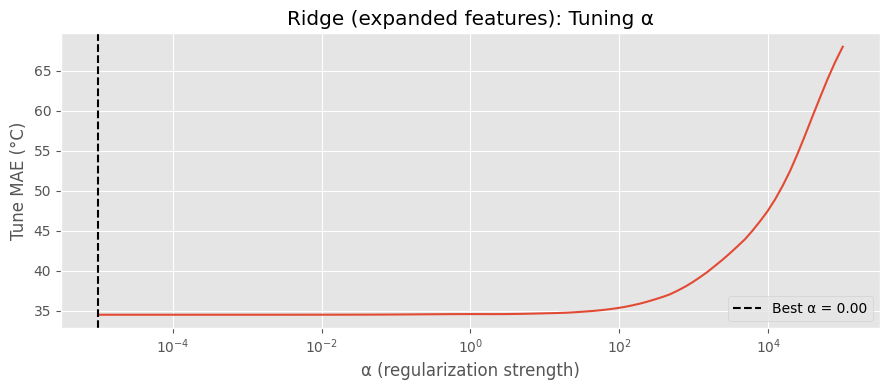

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas, tune_maes)
ax.axvline(best_alpha, color="k", linestyle="--", label=f"Best α = {best_alpha:.2f}")
ax.set_xlabel("α (regularization strength)")
ax.set_ylabel("Tune MAE (°C)")
ax.set_title("Ridge (expanded features): Tuning α")
ax.legend()
plt.tight_layout()
plt.show()

## Test Set Evaluation

In [8]:
model = Ridge(alpha=best_alpha).fit(X_train_s, y_train)

ridge_preds = model.predict(X_test_s)
ridge_mae   = mean_absolute_error(y_test, ridge_preds)
ridge_rmse  = root_mean_squared_error(y_test, ridge_preds)
print(f"Ridge (expanded) — Test MAE:  {ridge_mae:.2f} °C")
print(f"Ridge (expanded) — Test RMSE: {ridge_rmse:.2f} °C")

# Baseline for comparison
BASELINE_MAE  = 40.26
BASELINE_RMSE = 54.59
print(f"\nBaseline ridge  — Test MAE:  {BASELINE_MAE:.2f} °C")
print(f"Baseline ridge  — Test RMSE: {BASELINE_RMSE:.2f} °C")
print(f"\nMAE  improvement: {BASELINE_MAE - ridge_mae:+.2f} °C")
print(f"RMSE improvement: {BASELINE_RMSE - ridge_rmse:+.2f} °C")

Ridge (expanded) — Test MAE:  33.53 °C
Ridge (expanded) — Test RMSE: 44.26 °C

Baseline ridge  — Test MAE:  40.26 °C
Baseline ridge  — Test RMSE: 54.59 °C

MAE  improvement: +6.73 °C
RMSE improvement: +10.33 °C


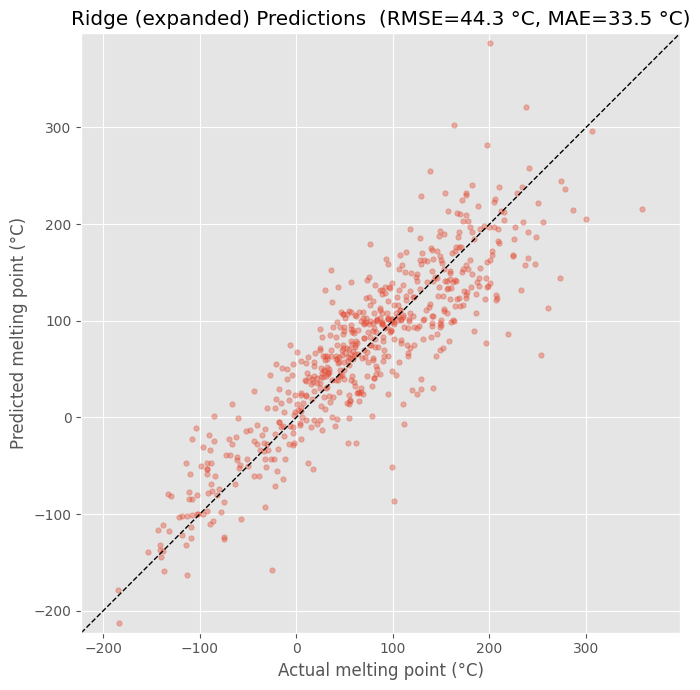

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, ridge_preds, alpha=0.4, s=15)
lims = [min(y_test.min(), ridge_preds.min()) - 10,
        max(y_test.max(), ridge_preds.max()) + 10]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual melting point (°C)")
ax.set_ylabel("Predicted melting point (°C)")
ax.set_title(f"Ridge (expanded) Predictions  (RMSE={ridge_rmse:.1f} °C, MAE={ridge_mae:.1f} °C)")
plt.tight_layout()
plt.show()

## Coefficients

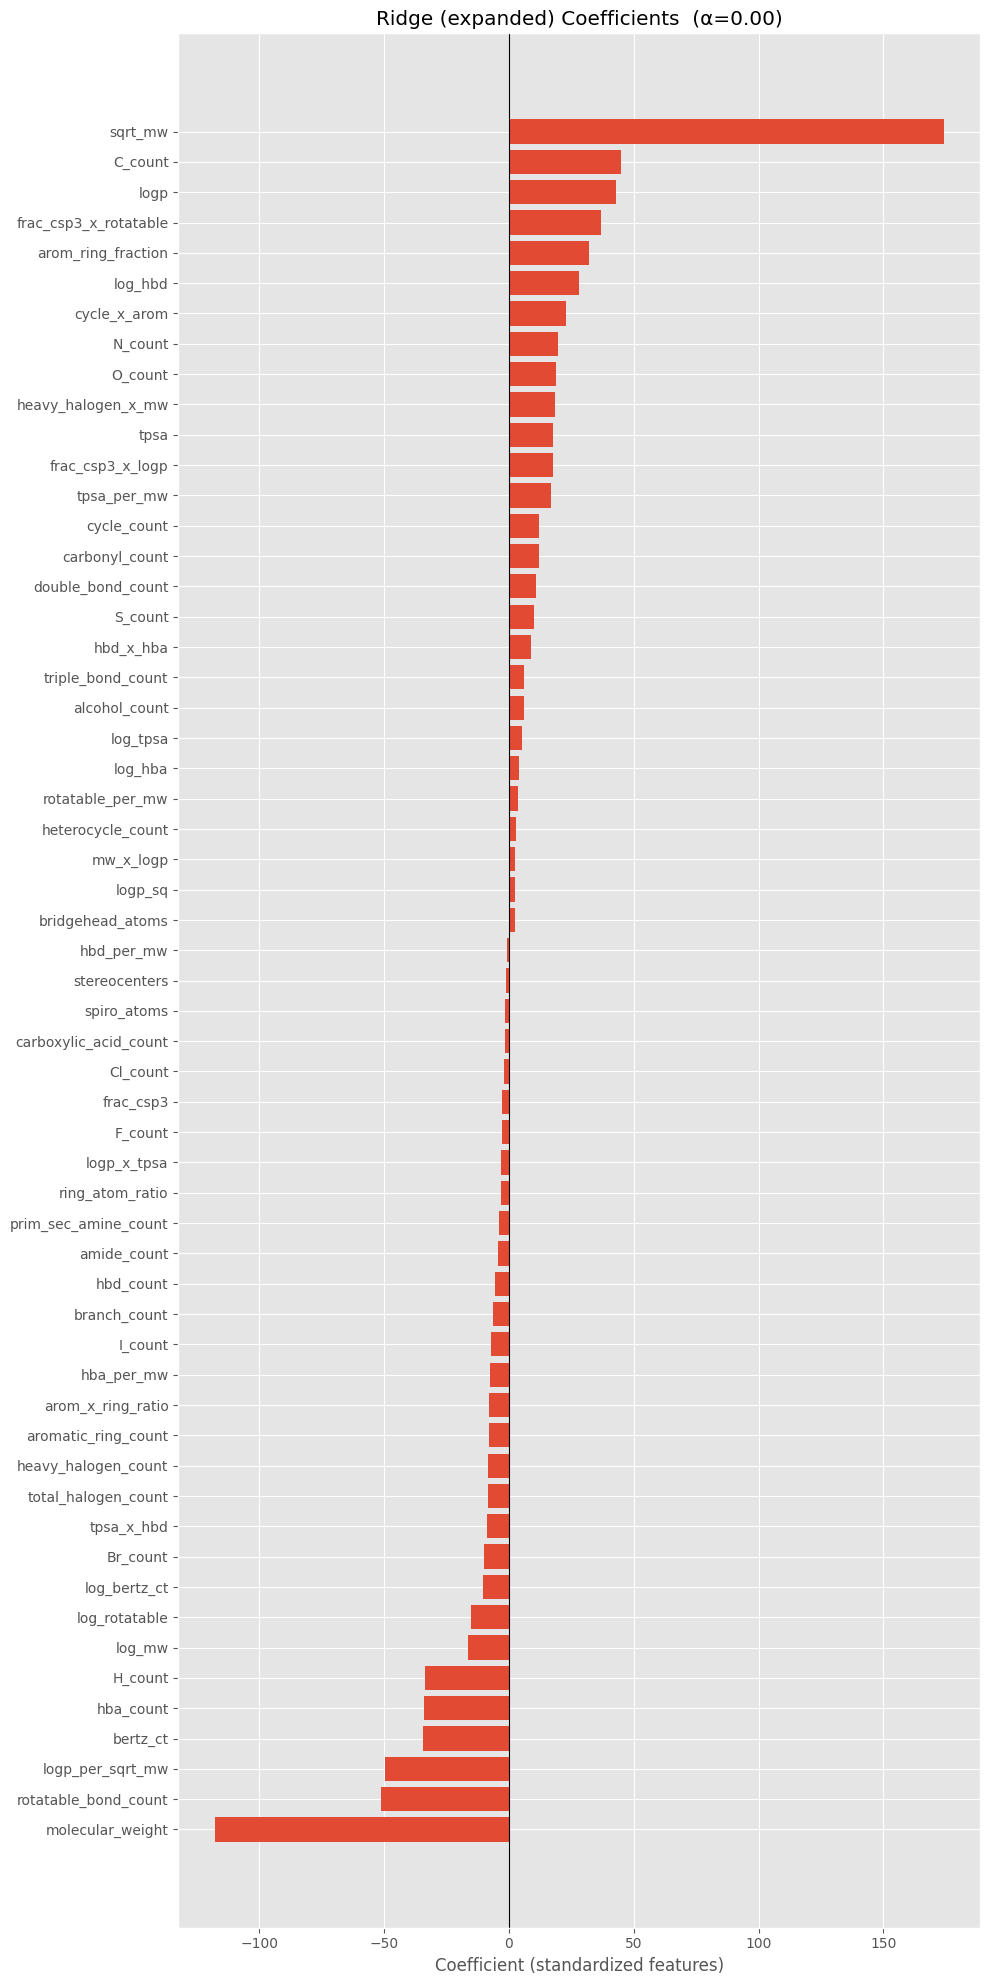

In [10]:
coef = model.coef_
sorted_idx = np.argsort(coef)

fig, ax = plt.subplots(figsize=(10, len(EXPANDED_COLS) * 0.35))
ax.barh([EXPANDED_COLS[i] for i in sorted_idx], coef[sorted_idx])
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized features)")
ax.set_title(f"Ridge (expanded) Coefficients  (α={best_alpha:.2f})")
plt.tight_layout()
plt.savefig("../img/ridge_expanded_coefs.png")
plt.show()

## Save Predictions

In [11]:
os.makedirs("../data/predictions", exist_ok=True)
(
    pl.DataFrame({
        "key":    keys_test.tolist(),
        "y_true": y_test.tolist(),
        "y_pred": ridge_preds.tolist(),
    })
    .write_parquet("../data/predictions/ridge_expanded_predictions.parquet")
)
print("Saved Ridge (expanded) test predictions.")

Saved Ridge (expanded) test predictions.
